# Insurance Risk Analytics - Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

## 2. LOAD DATASET

In [2]:
data_path = Path("../data/MachineLearningRating_v3.txt")

df = pd.read_csv(data_path, sep="|")

C:\Users\nbe\AppData\Local\Temp\ipykernel_5944\683810038.py:3: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path, sep="|")


## 3. PREVIEW DATA

In [3]:
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


## 4. DATASET SHAPE

In [4]:
df.shape

(1000098, 52)

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [6]:
df.dtypes

UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfDoors               

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
VehicleType                    552
make                           552
mmcode                         552
Model                          552
Cylinders                      552
bodytype                       552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
cubiccapacity                  552
CapitalOutstanding               2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

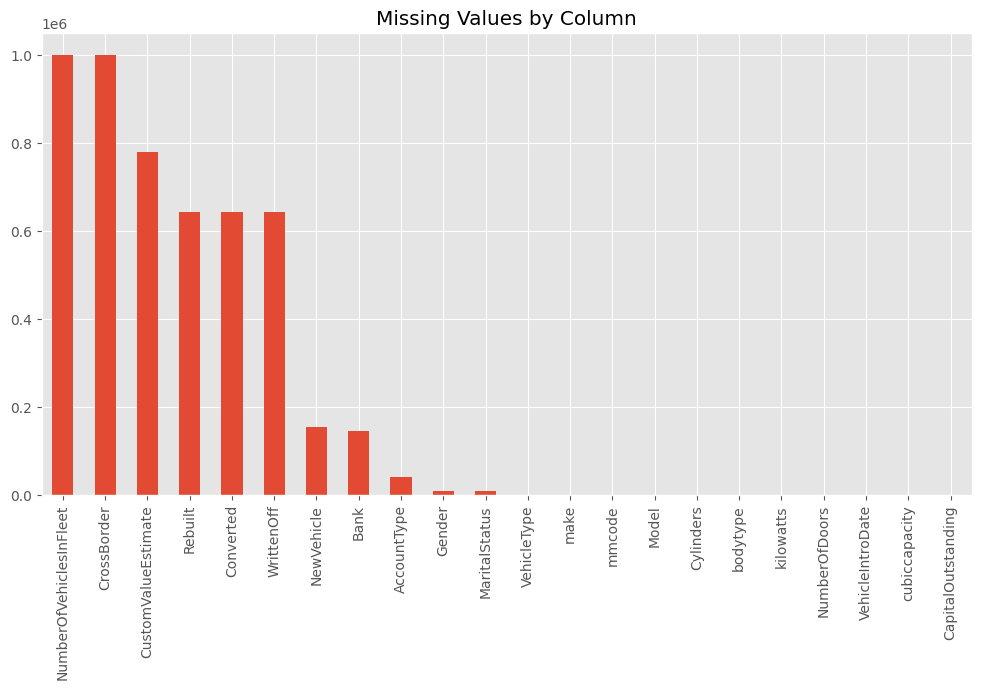

In [9]:
plt.figure(figsize=(12,6))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values by Column")
plt.show()

In [10]:
df.columns.tolist()

['UnderwrittenCoverID',
 'PolicyID',
 'TransactionMonth',
 'IsVATRegistered',
 'Citizenship',
 'LegalType',
 'Title',
 'Language',
 'Bank',
 'AccountType',
 'MaritalStatus',
 'Gender',
 'Country',
 'Province',
 'PostalCode',
 'MainCrestaZone',
 'SubCrestaZone',
 'ItemType',
 'mmcode',
 'VehicleType',
 'RegistrationYear',
 'make',
 'Model',
 'Cylinders',
 'cubiccapacity',
 'kilowatts',
 'bodytype',
 'NumberOfDoors',
 'VehicleIntroDate',
 'CustomValueEstimate',
 'AlarmImmobiliser',
 'TrackingDevice',
 'CapitalOutstanding',
 'NewVehicle',
 'WrittenOff',
 'Rebuilt',
 'Converted',
 'CrossBorder',
 'NumberOfVehiclesInFleet',
 'SumInsured',
 'TermFrequency',
 'CalculatedPremiumPerTerm',
 'ExcessSelected',
 'CoverCategory',
 'CoverType',
 'CoverGroup',
 'Section',
 'Product',
 'StatutoryClass',
 'StatutoryRiskType',
 'TotalPremium',
 'TotalClaims']

In [11]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

In [12]:
df[["LossRatio", "Margin"]].head()

,LossRatio,Margin
0,0.0,21.929825
1,0.0,21.929825
2,NaN,0.000000
3,0.0,512.848070
4,NaN,0.000000


In [13]:
numeric_fix_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "CapitalOutstanding",
]

for col in numeric_fix_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

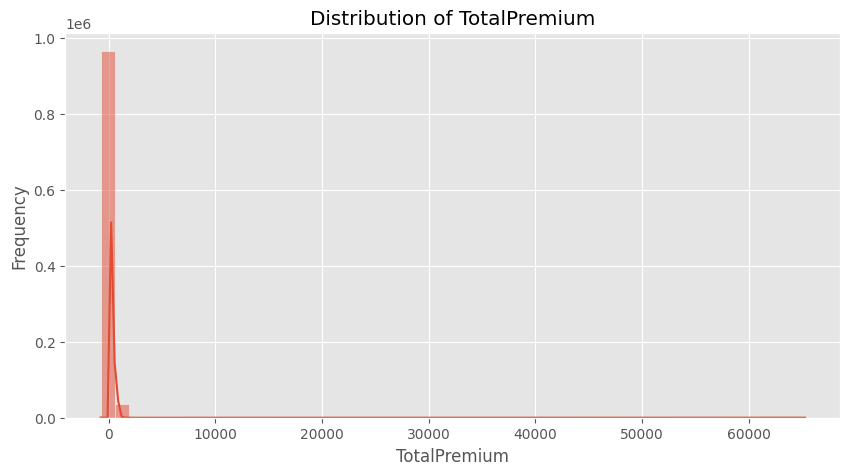

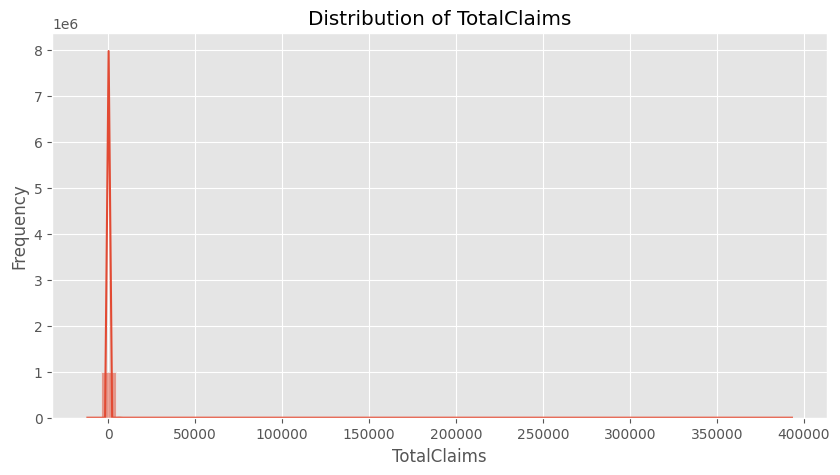

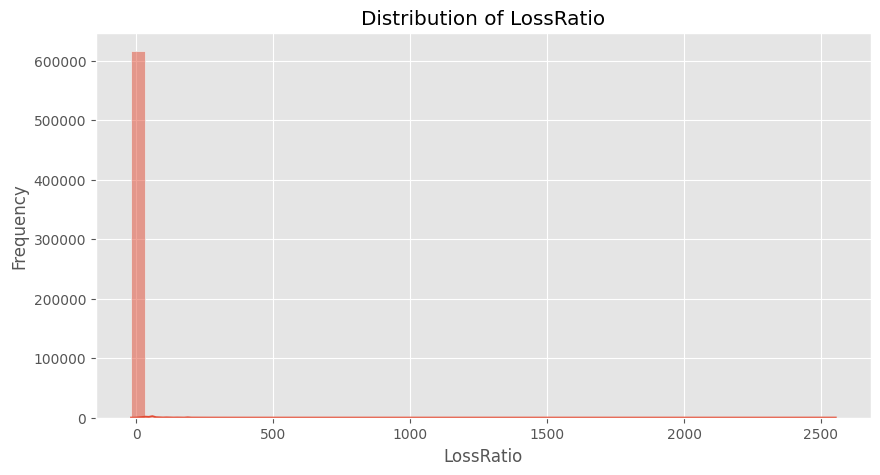

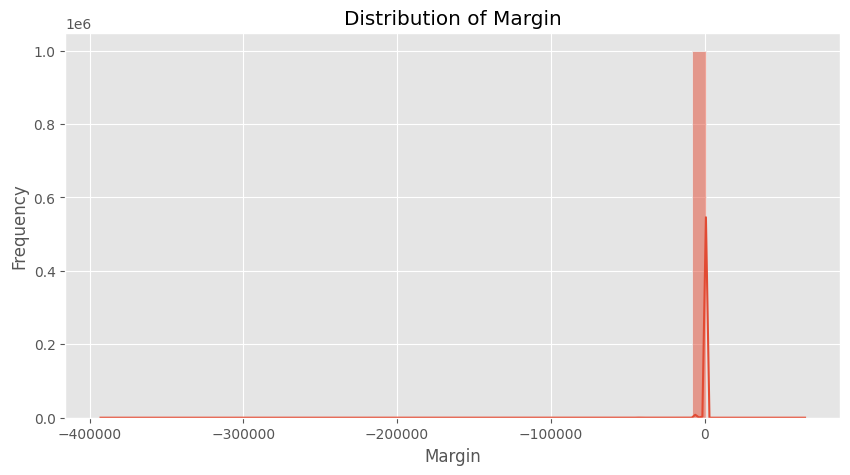

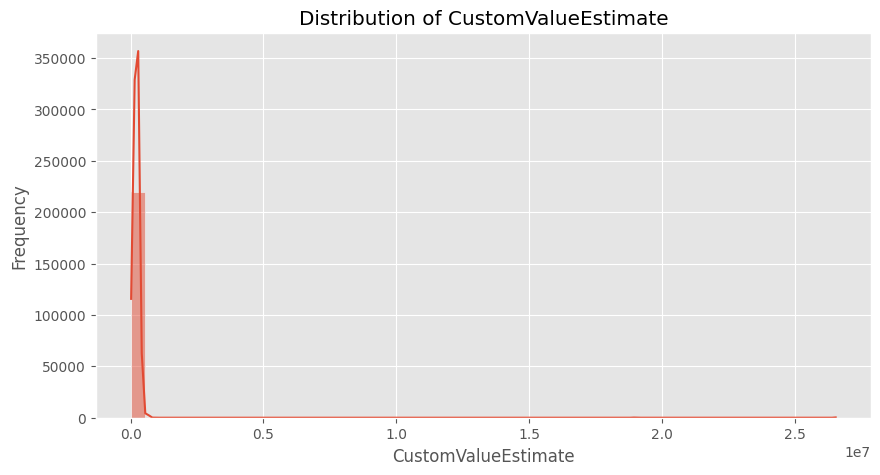

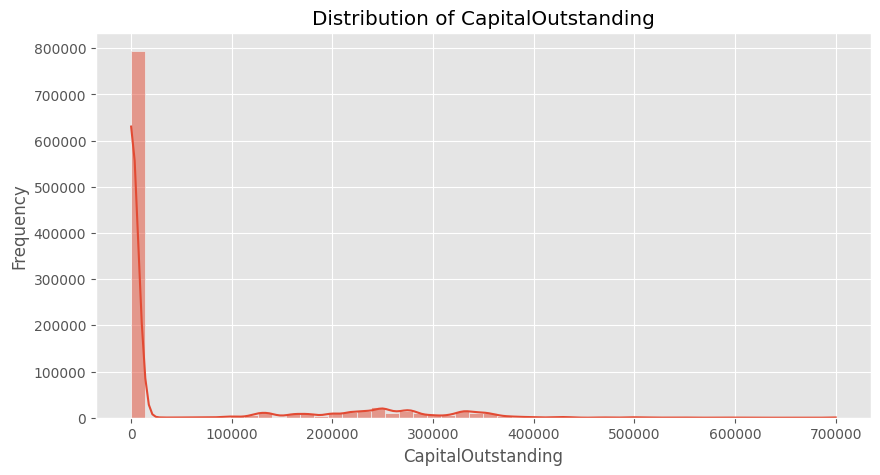

In [14]:
numerical_cols = [
    "TotalPremium",
    "TotalClaims",
    "LossRatio",
    "Margin",
    "CustomValueEstimate",
    "CapitalOutstanding",
]

for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        df[col].dropna(), 
        bins=50, 
        kde=True
        )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

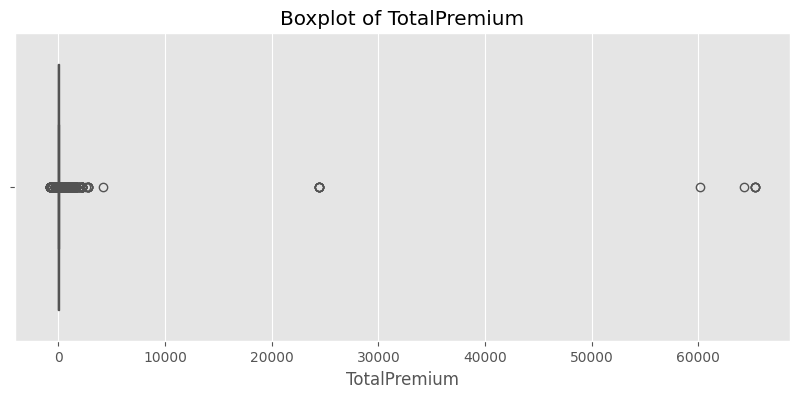

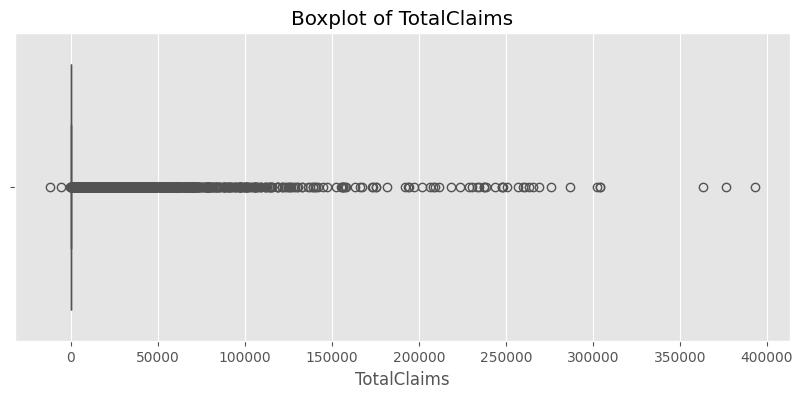

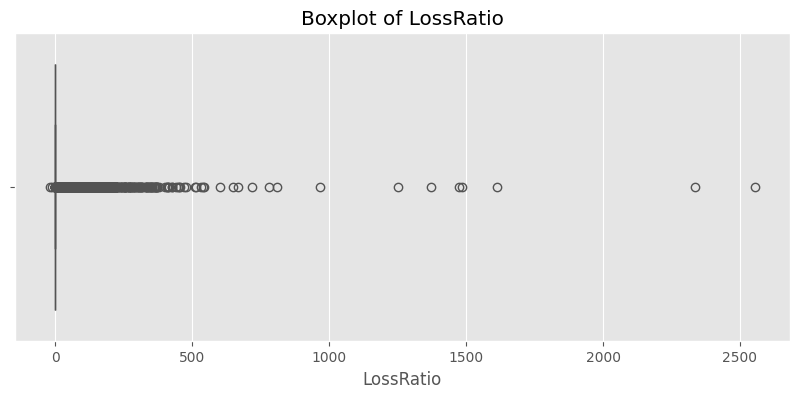

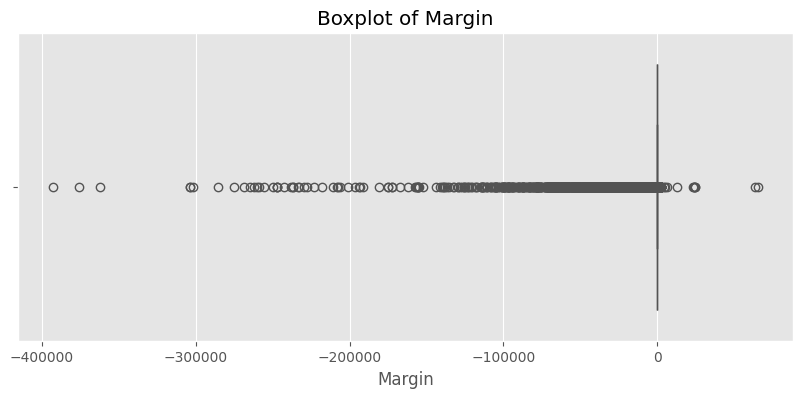

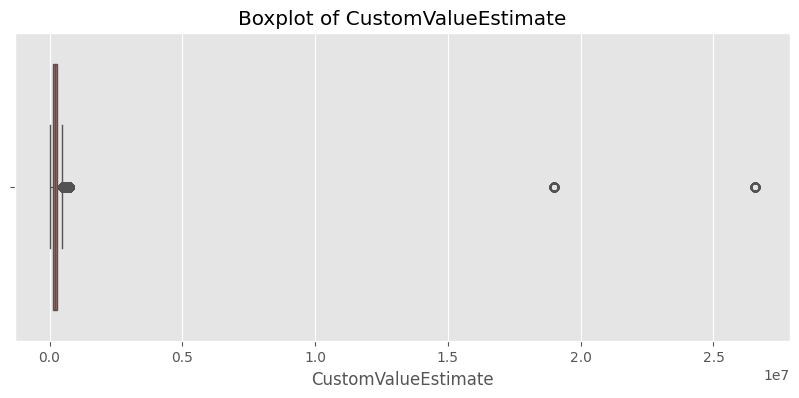

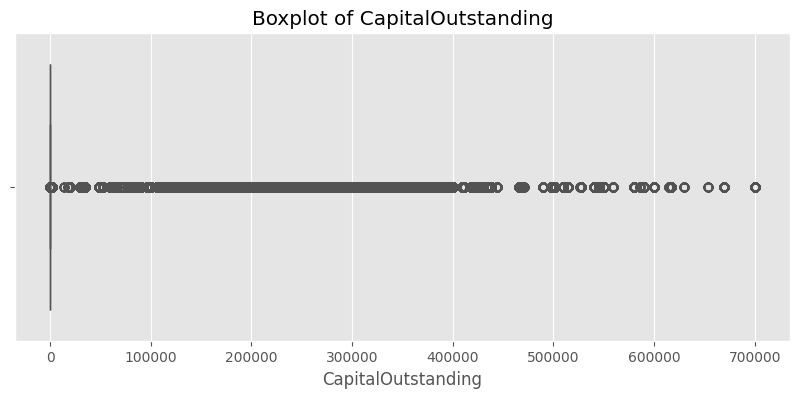

In [26]:
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

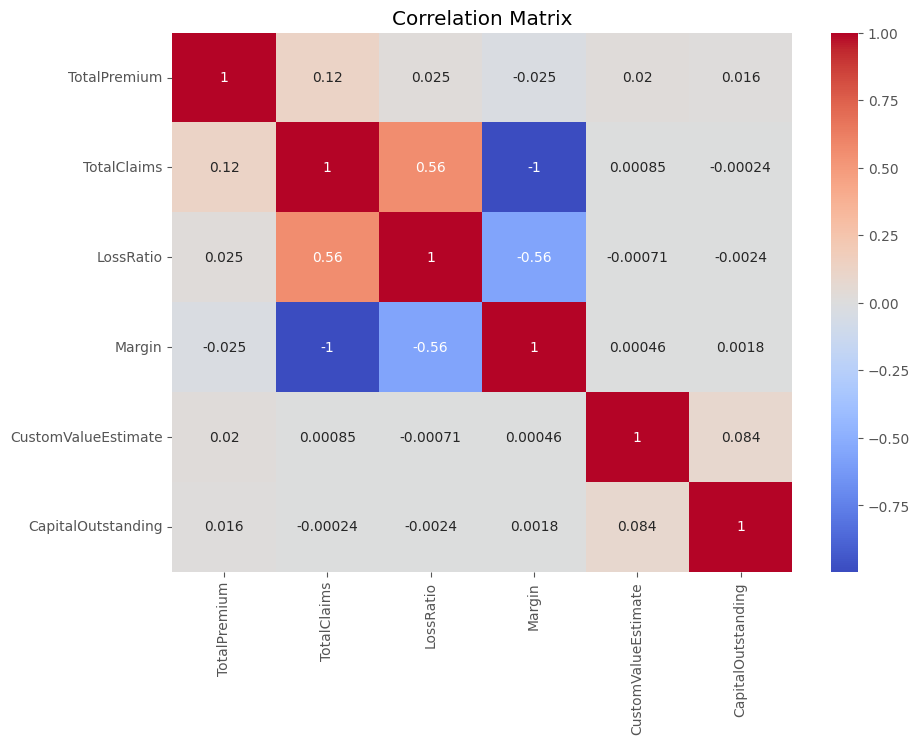

In [16]:
correlation_cols = [ 
    "TotalPremium", 
    "TotalClaims", 
    "LossRatio", 
    "Margin", 
    "CustomValueEstimate", 
    "CapitalOutstanding", 
    ] 
correlation_matrix = ( 
    df[correlation_cols] .corr() 
    ) 
plt.figure(figsize=(10, 7)) 
sns.heatmap( 
    correlation_matrix, 
    annot=True, 
    cmap="coolwarm" 
    ) 
plt.title("Correlation Matrix") 
plt.show()

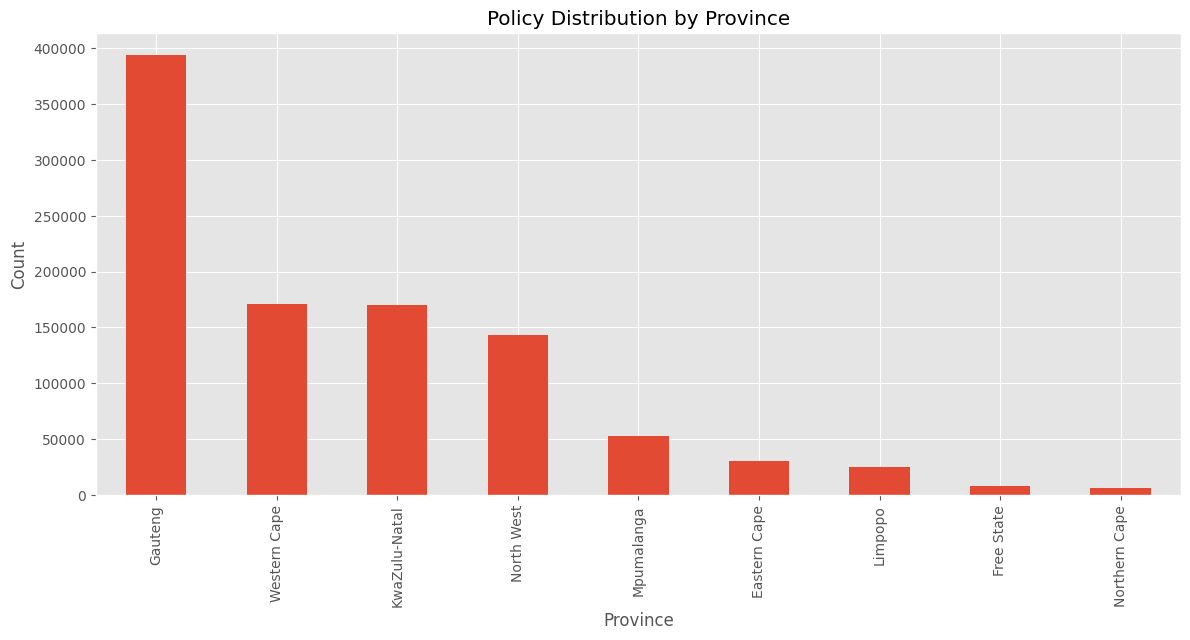

In [17]:
plt.figure(figsize=(14, 6)) 
df["Province"].value_counts().plot( 
    kind="bar" 
    ) 
plt.title("Policy Distribution by Province") 
plt.xlabel("Province") 
plt.ylabel("Count") 
plt.show()

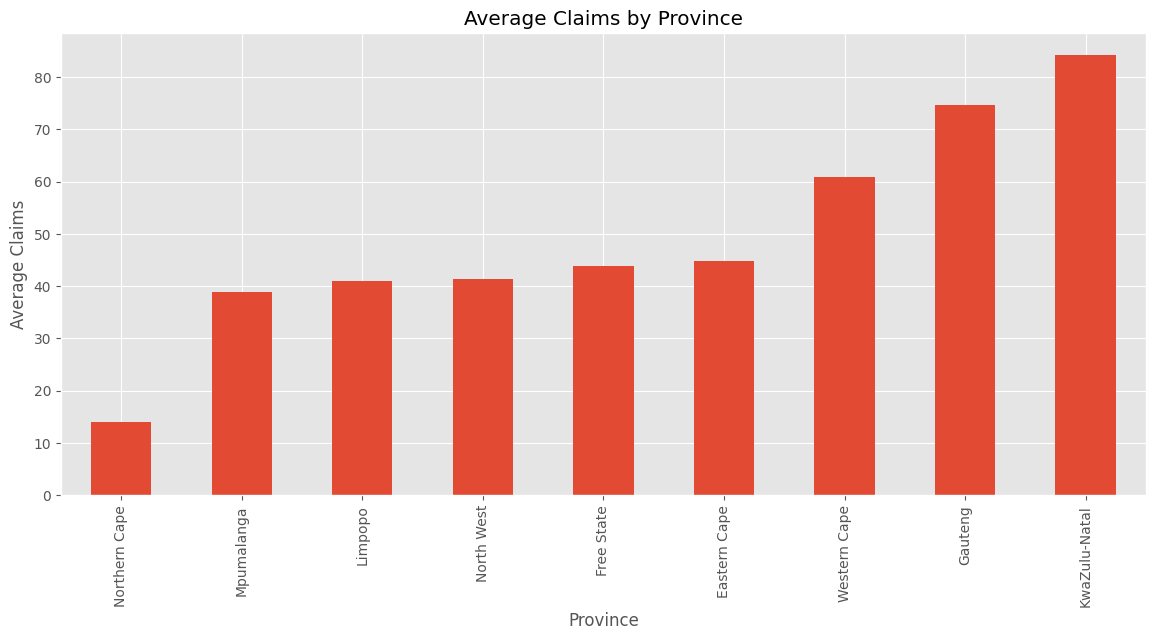

In [27]:
province_claims = (
    df.groupby("Province")["TotalClaims"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(14, 6))
province_claims.plot(kind="bar")
plt.title("Average Claims by Province")
plt.xlabel("Province")
plt.ylabel("Average Claims")
plt.show()

c:\Users\nbe\insurance-risk-analytics\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\nbe\insurance-risk-analytics\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


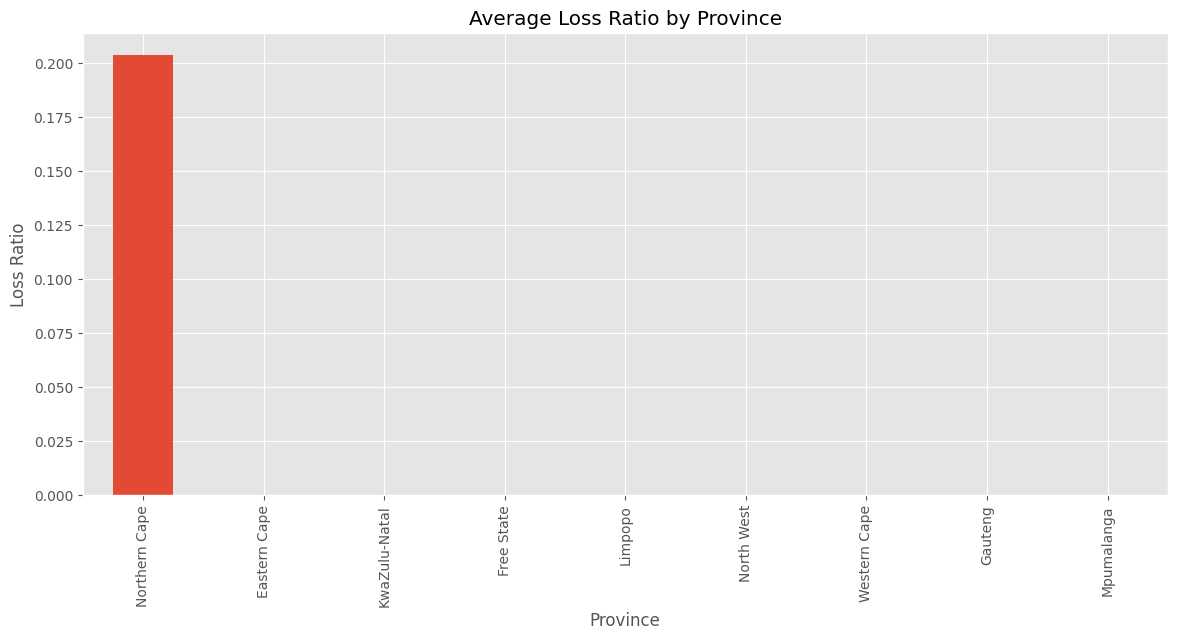

In [28]:
province_loss_ratio = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(14, 6))
province_loss_ratio.plot(kind="bar")
plt.title("Average Loss Ratio by Province")
plt.xlabel("Province")
plt.ylabel("Loss Ratio")
plt.show()

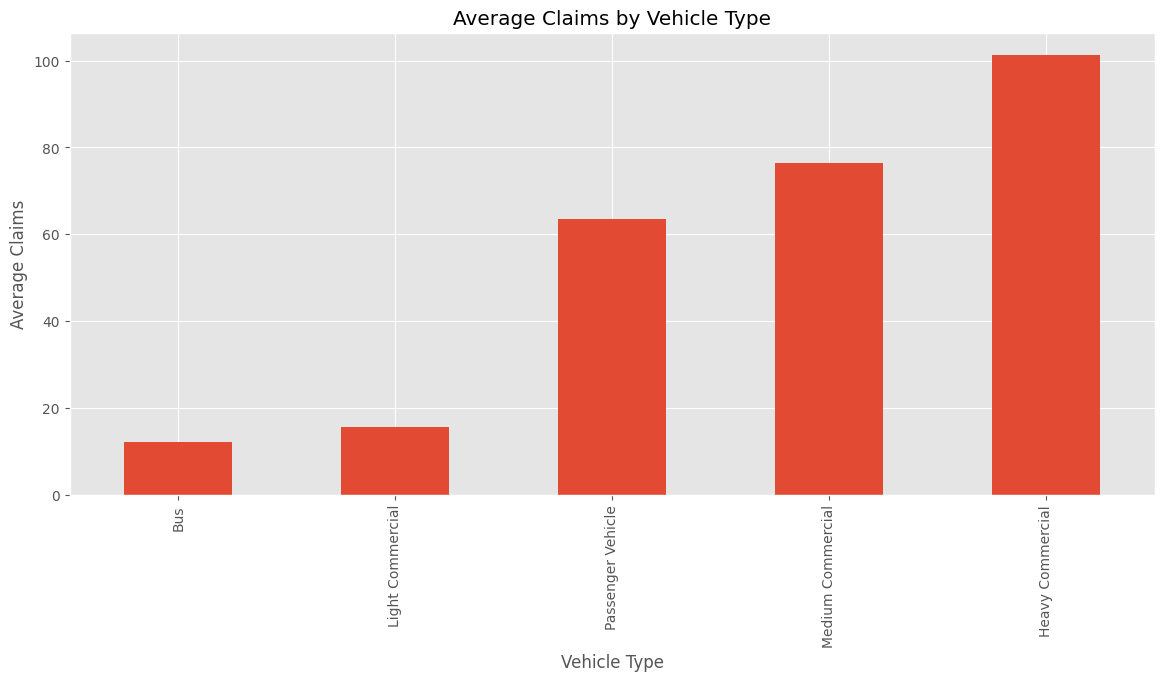

In [29]:
vehicle_claims = (
    df.groupby("VehicleType")["TotalClaims"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(14, 6))
vehicle_claims.plot(kind="bar")
plt.title("Average Claims by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Claims")
plt.show()

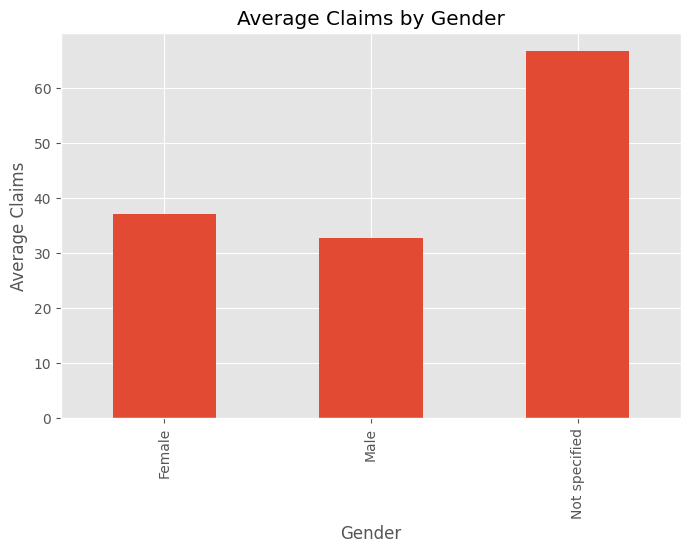

In [30]:
gender_claims = df.groupby("Gender")["TotalClaims"].mean()

plt.figure(figsize=(8, 5))
gender_claims.plot(kind="bar")
plt.title("Average Claims by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Claims")
plt.show()

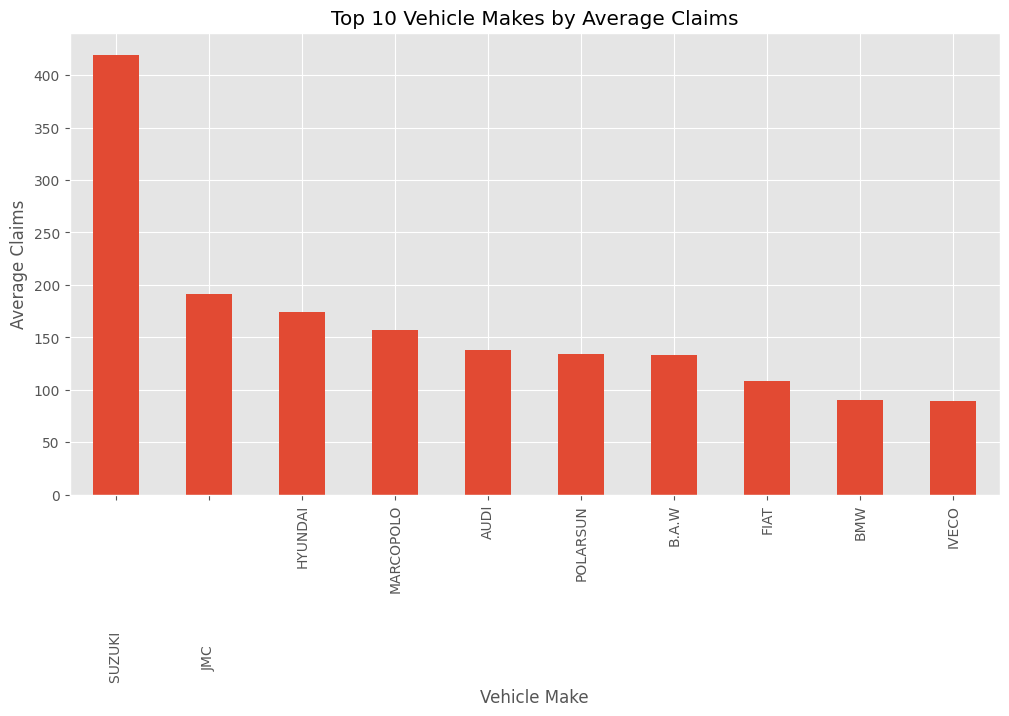

In [31]:
top_make_claims = (
    df.groupby("make")["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_make_claims.plot(kind="bar")
plt.title("Top 10 Vehicle Makes by Average Claims")
plt.xlabel("Vehicle Make")
plt.ylabel("Average Claims")
plt.show()

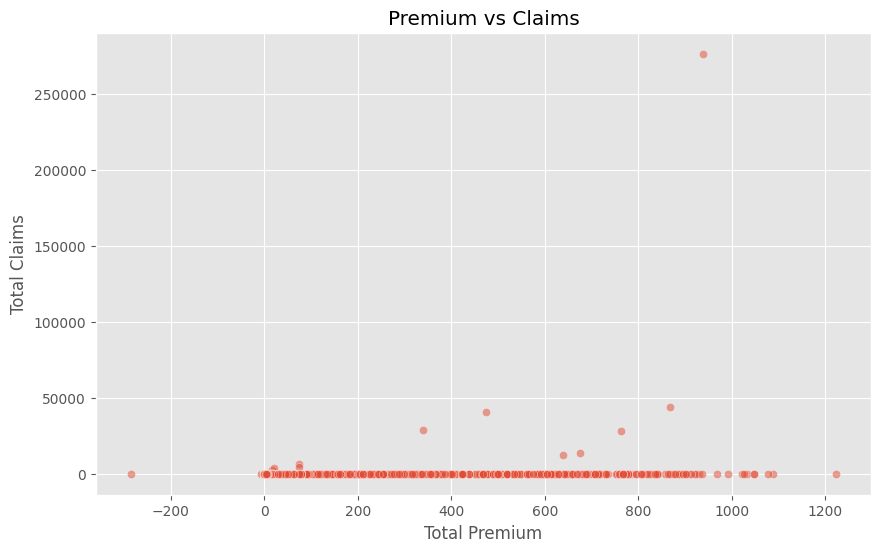

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="TotalPremium",
    y="TotalClaims",
    alpha=0.5
)

plt.title("Premium vs Claims")
plt.xlabel("Total Premium")
plt.ylabel("Total Claims")
plt.show()

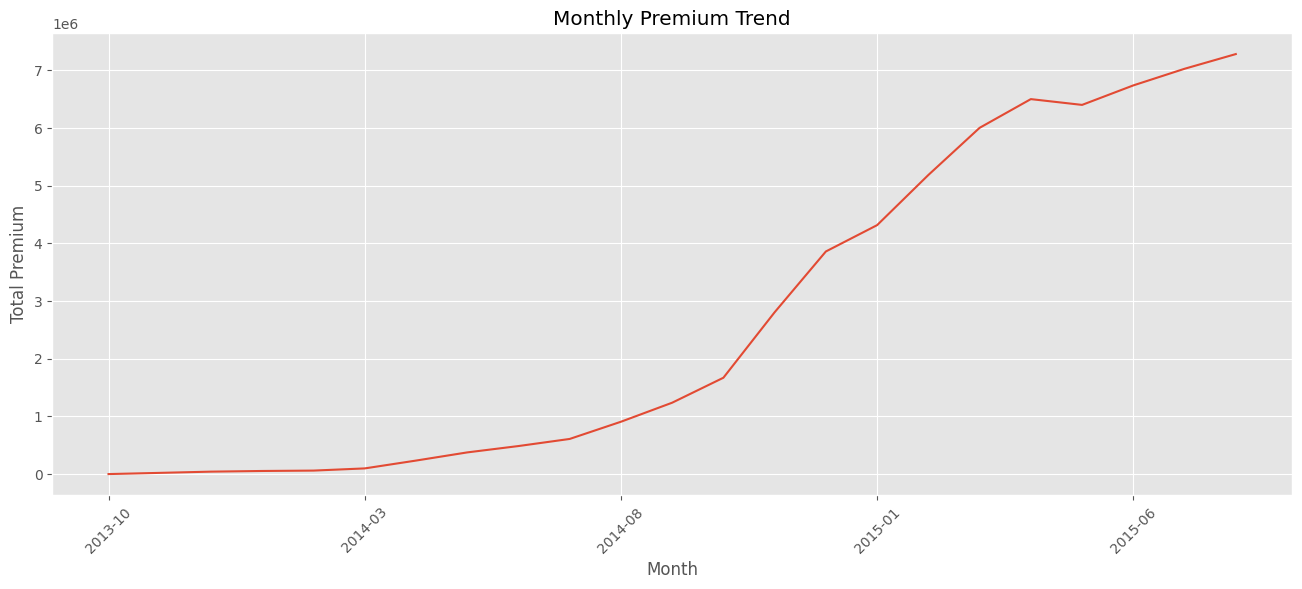

In [33]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"], errors="coerce")

monthly_premium = (
    df.groupby(df["TransactionMonth"].dt.to_period("M"))["TotalPremium"]
    .sum()
)

monthly_premium.index = monthly_premium.index.astype(str)

plt.figure(figsize=(16, 6))
monthly_premium.plot()
plt.title("Monthly Premium Trend")
plt.xlabel("Month")
plt.ylabel("Total Premium")
plt.xticks(rotation=45)
plt.show()

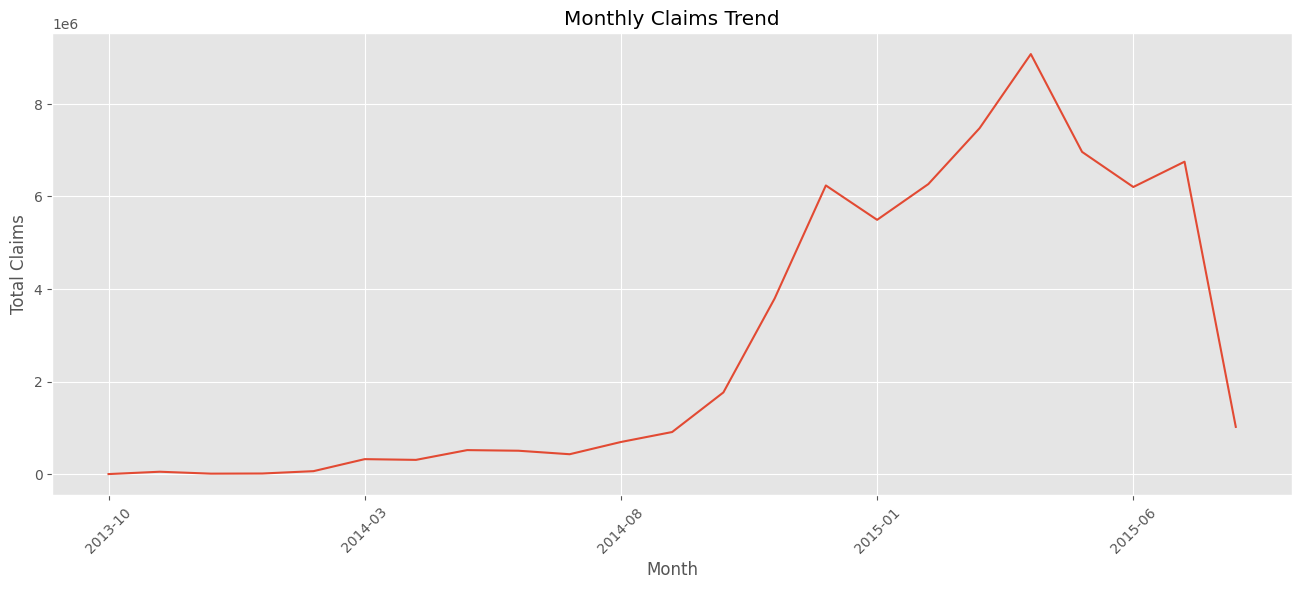

In [34]:
monthly_claims = (
    df.groupby(df["TransactionMonth"].dt.to_period("M"))["TotalClaims"]
    .sum()
)

monthly_claims.index = monthly_claims.index.astype(str)

plt.figure(figsize=(16, 6))
monthly_claims.plot()
plt.title("Monthly Claims Trend")
plt.xlabel("Month")
plt.ylabel("Total Claims")
plt.xticks(rotation=45)
plt.show()

In [35]:
high_risk_provinces = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

high_risk_provinces

Province
Eastern Cape     inf
Free State       inf
KwaZulu-Natal    inf
Limpopo          inf
North West       inf
Name: LossRatio, dtype: float64

In [36]:
high_risk_vehicle_types = (
    df.groupby("VehicleType")["LossRatio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

high_risk_vehicle_types

VehicleType
Bus                       inf
Heavy Commercial          inf
Medium Commercial         inf
Light Commercial     0.543917
Passenger Vehicle         NaN
Name: LossRatio, dtype: float64

In [37]:
business_summary = (
    df.groupby("Province")
    .agg({
        "TotalPremium": "mean",
        "TotalClaims": "mean",
        "LossRatio": "mean"
    })
    .sort_values(by="LossRatio", ascending=False)
)

business_summary.head(10)

,TotalPremium,TotalClaims,LossRatio
Province,,,
Eastern Cape,70.546672,44.713432,inf
Free State,64.373780,43.822975,inf
KwaZulu-Natal,77.800695,84.234293,inf
Limpopo,61.899038,40.927553,inf
North West,52.276258,41.317426,inf
Western Cape,57.416793,60.831482,inf
Northern Cape,49.617253,14.026726,0.203831
Gauteng,61.071115,74.630009,NaN
Mpumalanga,53.801205,38.785147,NaN


## Business Insight Summary (Loss Ratio Analysis)

The Loss Ratio results highlight major data quality issues affecting interpretation, with several provinces and vehicle types showing **infinite or NaN values**, likely caused by missing or zero premium records.

KwaZulu-Natal records the highest claims activity, but its loss ratio is unreliable due to inconsistent or incomplete premium data. Western Cape shows a more stable premium-to-claims relationship, while Northern Cape stands out with a low and valid loss ratio (0.20), indicating better profitability or lower risk exposure.

On vehicle types, commercial categories such as Bus and Heavy Commercial vehicles show infinite loss ratios, signaling serious data inconsistencies. Light Commercial vehicles show a more realistic and moderate risk level (0.54), while Passenger Vehicles lack sufficient data for evaluation.

### Key Takeaway
The dataset must be cleaned before making business decisions. Current loss ratios reflect **data issues more than true insurance risk patterns**.